# **Dataset API Prototype**

In [158]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm.notebook import tqdm
import os
import matplotlib.pyplot as plt


## WM_811K Dataset Class

In [250]:
class WM_811K():

    defect_to_int = {
        'none'      : -1,
        'Center'    :  0,
        'Loc'       :  1,
        'Edge-Ring' :  2,
        'Edge-Loc'  :  3,
        'Scratch'   :  4,
        'Random'    :  5,
        'Donut'     :  6,
        'Near-full' :  7,
    }

    defect_from_int = { v:k for k,v in WM_811K.defect_to_int.items() }

    n_classes = len(WM_811K.defect_to_int)


    def __init__(self, imsize=(64,64)):
        self.imsize = imsize
        self.class_samples = { i: [] for i in WM_811K.defect_from_int }

        print('reading wafermaps')
        path = os.path.join('..', 'data', 'LSWMD_slimmed.pkl')
        df = pd.read_pickle(path)
        for row in tqdm(df.itertuples(index=False), total=len(df)):
            i = WM_811K.defect_to_int[row.label]

            # TODO: remove --- temporarily use smaller subset for faster loading
            if len(self.class_samples[i]) >= 100:
                continue

            img = self.preprocess_image(row.waferMap)
            self.class_samples[i].append(img)


    def preprocess_image(self, img: 'tf.Tensor|np.array'):
        img = tf.convert_to_tensor(img, dtype=tf.float32)
        img = tf.squeeze(img)
        img = tf.expand_dims(img, -1)
        img = tf.maximum(img - 1.0, 0.0)
        img = tf.image.resize(img, self.imsize)
        return img


    def augment_image(self, img: tf.Tensor):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=np.random.randint(4))
        img = tf.minimum(img * (1.0 + np.random.rand()), 1.0)
        return img


    def dataset_single_defect(self):
        def _generator():
            while True:
                label = np.random.randint(WM_811K.n_classes) - 1
                samples = self.class_samples[label]
                img = samples[np.random.randint(len(samples))]
                img = self.augment_image(img)
                yield (img, tf.one_hot(label, depth=WM_811K.n_classes-1))
        
        return tf.data.Dataset.from_generator(_generator,
            output_types=(tf.float32, tf.float32),
            output_shapes=((*self.imsize, 1), (WM_811K.n_classes - 1,)),
        ).repeat()
    

    def __create_multi_defect_sample(self):
        input_img = tf.zeros((*self.imsize, 1))
        channels = [tf.zeros(self.imsize) for _ in range(WM_811K.n_classes - 1)]
        label_vec = tf.zeros((WM_811K.n_classes - 1))
        
        class_probabilities = np.random.rand(WM_811K.n_classes - 1) * np.random.randint(10)     # class picking order * occasional none 
        while np.sum(class_probabilities) > 0.0:
            # get an image sample
            label = np.argmax(class_probabilities)
            samples = self.class_samples[label]
            img = samples[np.random.randint(len(samples))]
            img = self.augment_image(img)

            # roughly check how much information will be lost/gained
            total = tf.reduce_sum(input_img) + 0.1
            inf_loss = tf.reduce_sum(input_img - tf.maximum(input_img - img, 0.0))
            inf_gain = tf.reduce_sum(tf.maximum(img - input_img, 0.0))

            # ...and add img to total if acceptable
            if inf_loss < .25 * total and inf_gain > .25 * total:    
                input_img = tf.maximum(input_img, img)
                channels[label] = tf.squeeze(img)
                label_vec = tf.maximum(label_vec, tf.one_hot(label, depth=WM_811K.n_classes-1))

            class_probabilities[label] = 0.0

        img_stack = tf.stack(channels, axis=-1)
        return input_img, img_stack, label_vec


    def dataset_multi_defect_segmentation(self):
        def _generator():
            while True:
                x,y,_ = self.__create_multi_defect_sample()
                yield x,y

        return tf.data.Dataset.from_generator(_generator,
            output_types=(tf.float32, tf.float32),
            output_shapes=((*self.imsize,1), (*self.imsize, WM_811K.n_classes - 1)),
        ).repeat()


    def dataset_multi_defect_classification(self):
        def _generator():
            while True:
                _,x,y = self.__create_multi_defect_sample()
                yield x,y
            
        return tf.data.Dataset.from_generator(_generator,
            output_types=(tf.float32, tf.float32),
            output_shapes=((*self.imsize, WM_811K.n_classes - 1), (WM_811K.n_classes - 1,))
        ).repeat()


    def dataset_multi_defect_fullstack(self):
        def _generator():
            while True:
                x,_,y = self.__create_multi_defect_sample()
                yield x,y
            
        return tf.data.Dataset.from_generator(_generator,
            output_types=(tf.float32, tf.float32),
            output_shapes=((*self.imsize,1), (WM_811K.n_classes - 1,))
        ).repeat()


In [251]:
# segmentation model
wm811k = WM_811K(imsize=(64,64))

reading wafermaps


  0%|          | 0/12822 [00:00<?, ?it/s]

## Single Defect Tensorflow Dataset

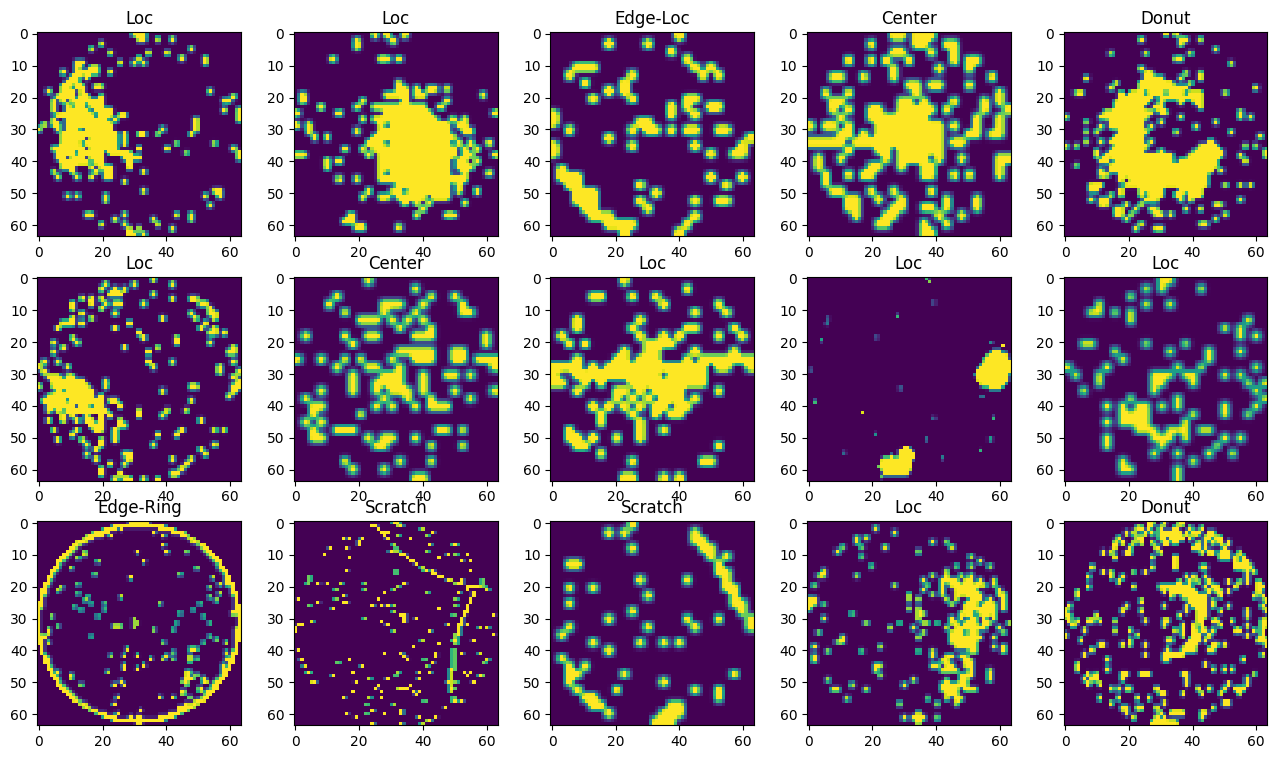

In [135]:
N_VIEW = 15
cols = min(N_VIEW, 5)
rows = (N_VIEW + cols - 1) // cols

_,axs = plt.subplots(rows,cols, figsize=(16,9))

ds = wm811k.dataset_single_defect()
for ax, (img, label) in zip(axs.flatten(), ds.take(N_VIEW)):
    ax.imshow(img)
    i = np.argmax(label) if np.sum(label) != 0.0 else -1
    ax.set_title(WM_811K.defect_from_int[i])
    

Edge-Loc


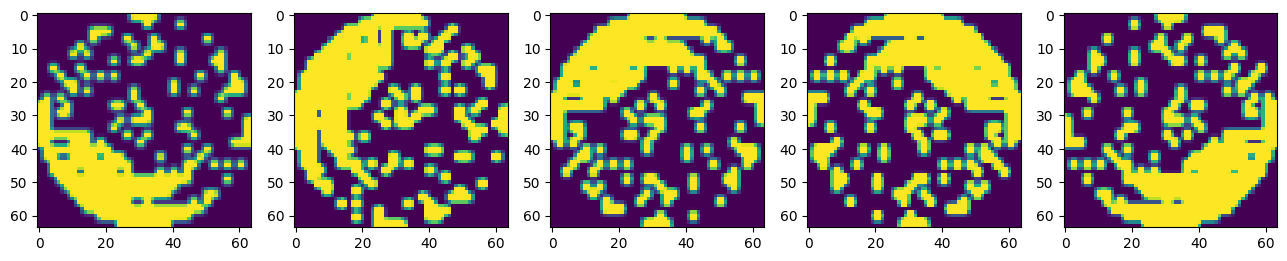

In [139]:
for img, label in ds.take(1):
    _, axs = plt.subplots(1,5, figsize=(16,4))
    axs[0].imshow(img)
    axs[1].imshow(wm811k.augment_image(img))
    axs[2].imshow(wm811k.augment_image(img))
    axs[3].imshow(wm811k.augment_image(img))
    axs[4].imshow(wm811k.augment_image(img))
    i = np.argmax(label) if np.sum(label) != 0.0 else -1
    print(WM_811K.defect_from_int[i])

## Multi Defect Tensorflow Dataset

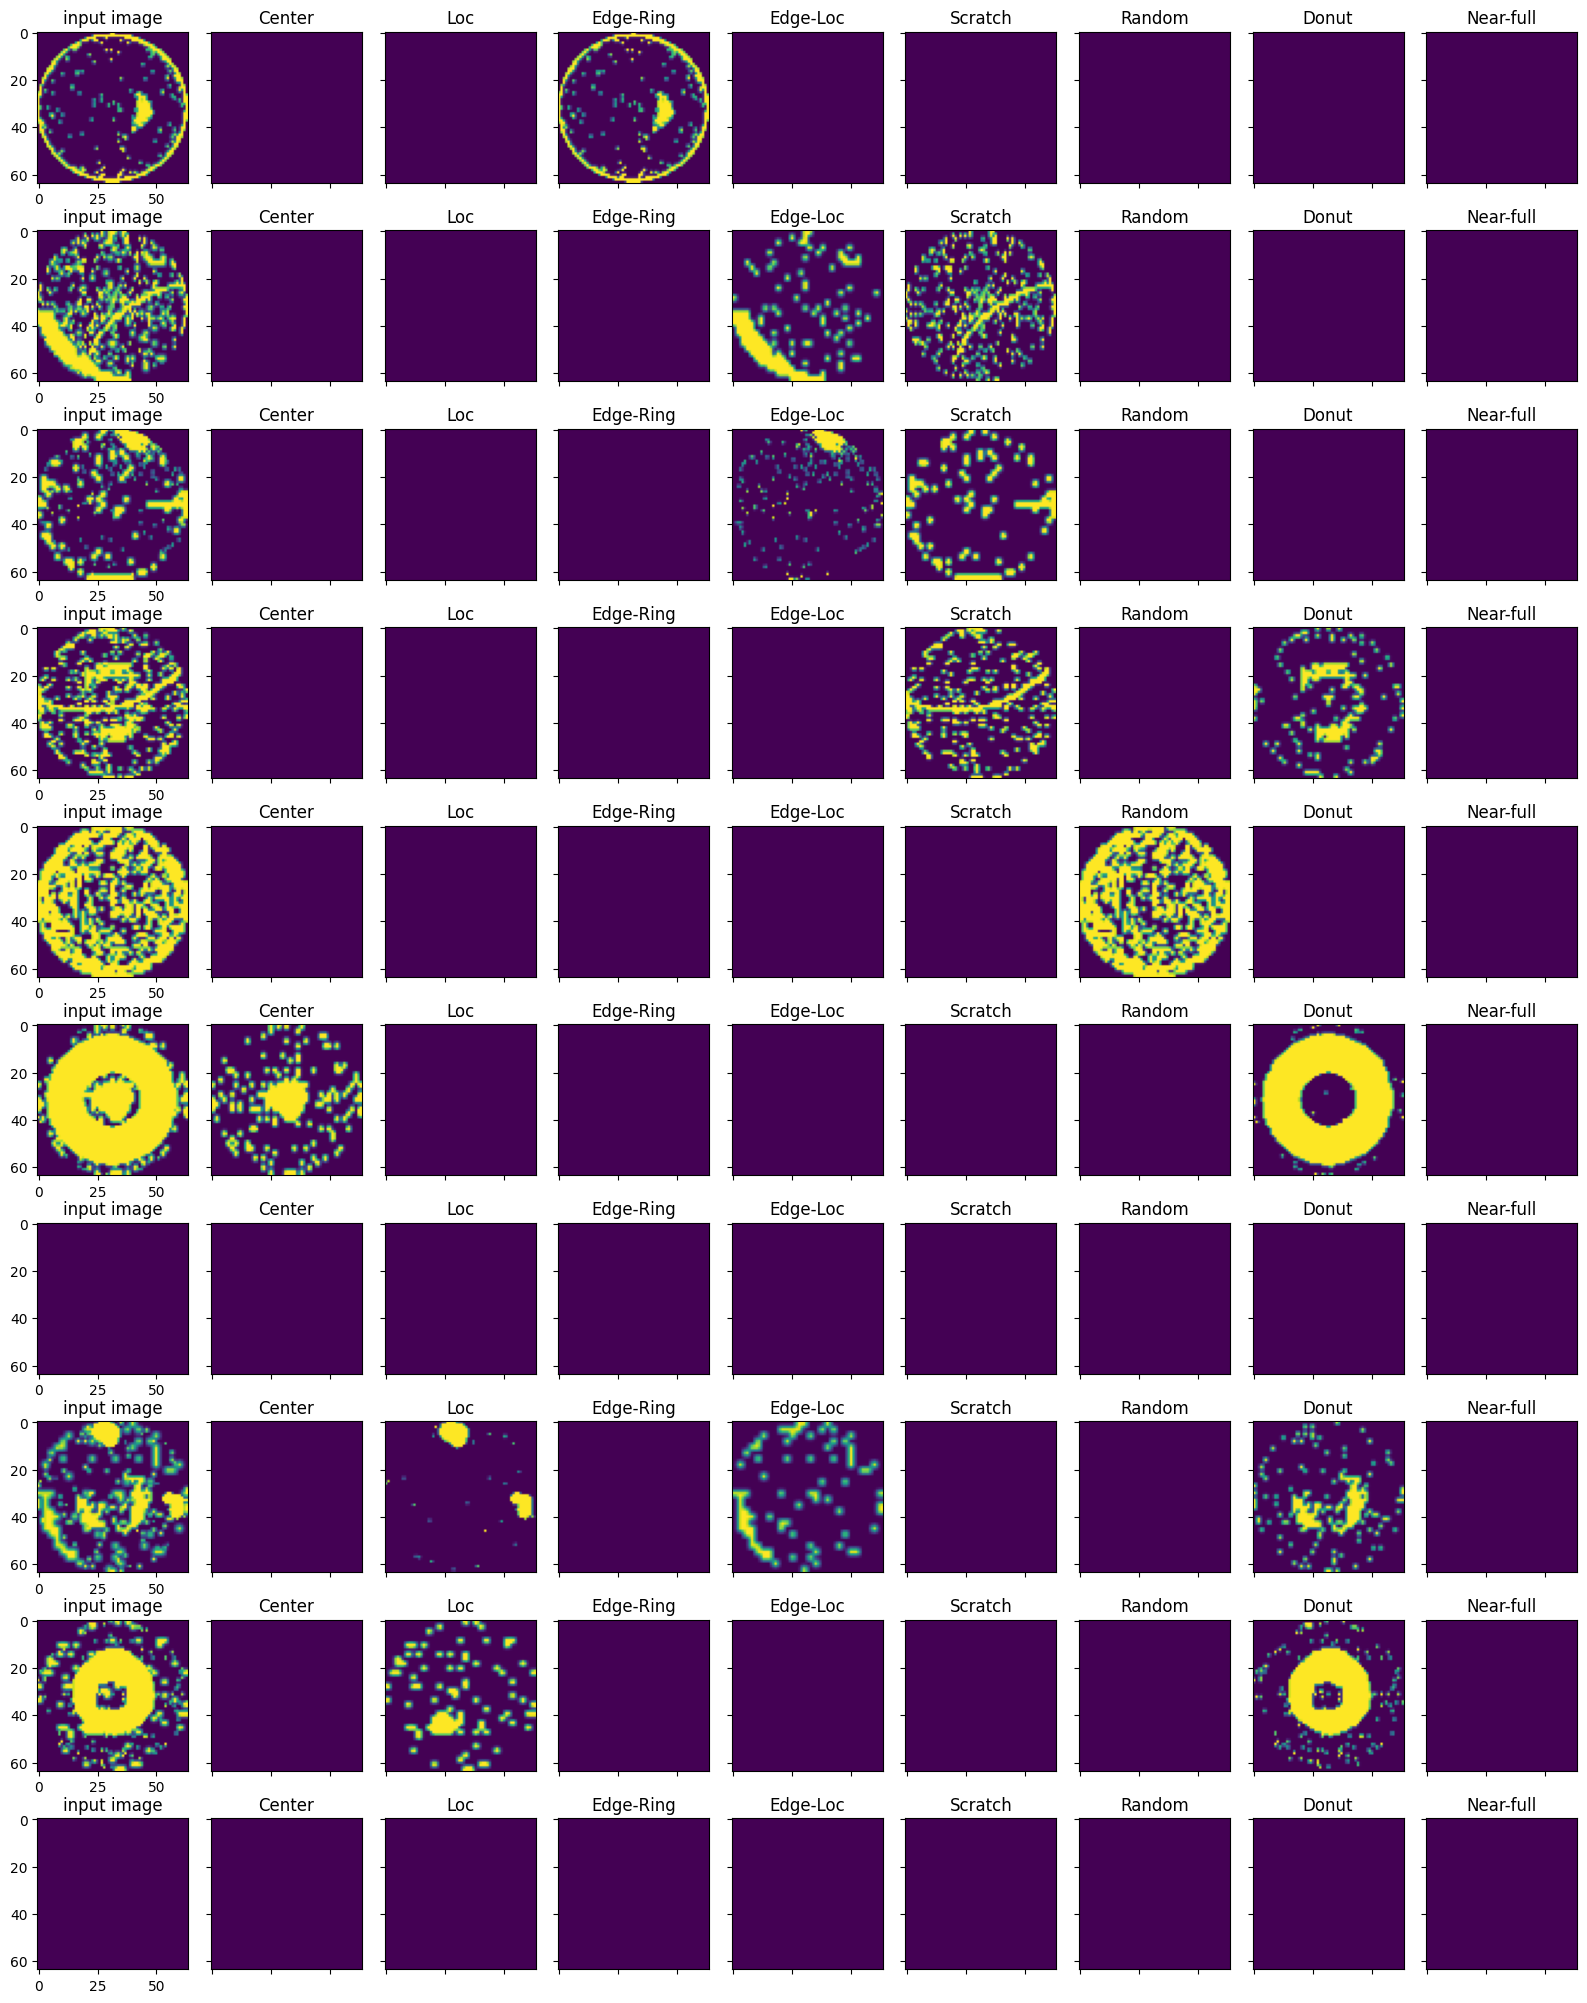

In [143]:
N_VIEW = 10
_,axs = plt.subplots(N_VIEW, 9, figsize=(16, 2*N_VIEW))

ds = wm811k.dataset_multi_defect_segmentation()
for row, (input_img, mid_stack) in enumerate(ds.take(N_VIEW)):
    axs[row,0].imshow(input_img)
    axs[row,0].set_title('input image')
    for col in range(8):
        axs[row,col+1].imshow(mid_stack[:,:,col])
        axs[row,col+1].set_title(WM_811K.defect_from_int[col])
        axs[row,col+1].set_xticklabels([])
        axs[row,col+1].set_yticklabels([])

plt.tight_layout()

## 1. Train Segmentation Model

In [163]:
model_segmentation = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(shape=(*wm811k.imsize, 1)),

    # convolution block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(0.25),

    # convolution block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(0.25),

    # transposed convolution block 1
    tf.keras.layers.Conv2DTranspose(64, (3, 3), activation='relu', strides=2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # transposed convolution block 2
    tf.keras.layers.Conv2DTranspose(32, (3, 3), activation='relu', strides=2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # transposed convolution block 3
    tf.keras.layers.Conv2DTranspose(8, (2, 2), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
])

model_segmentation.compile(
    loss=tf.keras.losses.MSE,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)

model_segmentation.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 30, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_25             │ (None, 31, 31, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 31, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_26             │ (None, 63, 63, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 63, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_27             │ (None, 64, 64, 8)      │         1,032 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 64, 64, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 64, 64, 8)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,040 (297.03 KB)

 Trainable params: 75,640 (295.47 KB)

 Non-trainable params: 400 (1.56 KB)

In [206]:
model_segmentation = tf.keras.models.load_model(os.path.join('..', 'models', 'multi_defect_segmentation.keras'))

In [207]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_segmentation.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
]

ds_train = wm811k.dataset_multi_defect_segmentation().batch(16)
ds_validation = wm811k.dataset_multi_defect_segmentation().batch(16)

history = model_segmentation.fit(
    x=ds_train,
    steps_per_epoch=128,
    validation_data=ds_validation,
    validation_steps=32,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - loss: 0.0836
Epoch 1: val_loss improved from None to 0.03977, saving model to ../models/multi_defect_segmentation.keras

Epoch 1: finished saving model to ../models/multi_defect_segmentation.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 119s 908ms/step - loss: 0.0774 - val_loss: 0.0398
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - loss: 0.0620
Epoch 2: val_loss improved from 0.03977 to 0.03396, saving model to ../models/multi_defect_segmentation.keras

Epoch 2: finished saving model to ../models/multi_defect_segmentation.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 119s 939ms/step - loss: 0.0581 - val_loss: 0.0340
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - loss: 0.0481
Epoch 3: val_loss improved from 0.03396 to 0.02586, saving model to ../models/multi_defect_segmentation.keras

Epoch 3: finished saving model to ../models/multi_defect_segmentation.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 121s 949ms/step - loss: 0.0462 - val_loss: 0.025

In [208]:
sample = list(ds_train.take(1))
pred = model_segmentation.predict(sample)

/home/mwerner/uni/s26/Data Analysis/NTU_DA_Final_Project/env/lib/python3.12/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_11
Received: inputs=(('Tensor(shape=(16, 64, 64, 1))', 'Tensor(shape=(16, 64, 64, 8))'),)
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step


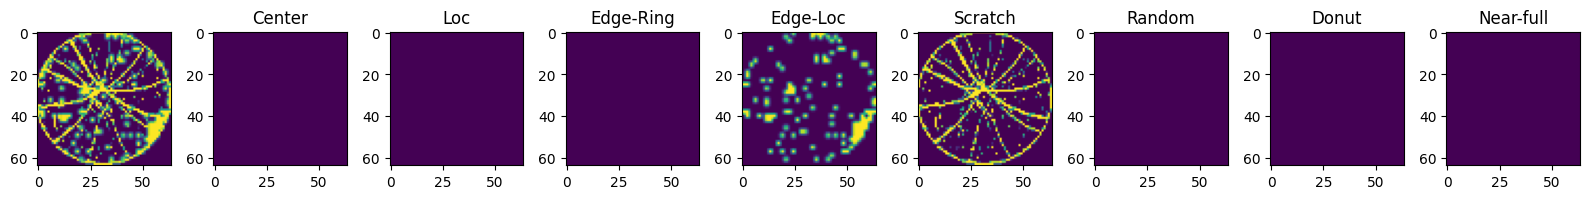

In [246]:
idx = 4
input_img, img_stack = sample[0]
_,axs = plt.subplots(1,9, figsize=(16,3))
axs[0].imshow(input_img[idx,:,:,0])
for c in range(8):
    axs[c+1].imshow(img_stack[idx,:,:,c])
    axs[c+1].set_title(WM_811K.defect_from_int[c])
plt.tight_layout()

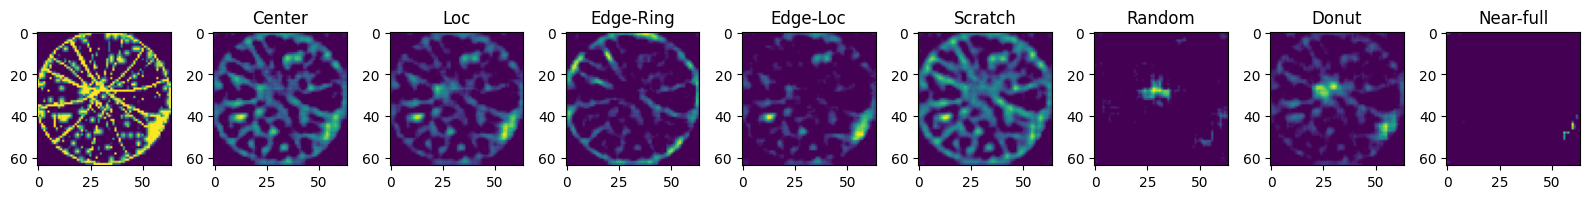

In [247]:
_,axs = plt.subplots(1,9, figsize=(16,3))
axs[0].imshow(input_img[idx,:,:,0])
for c in range(8):
    axs[c+1].imshow(pred[idx,:,:,c])
    axs[c+1].set_title(WM_811K.defect_from_int[c])
plt.tight_layout()

## 2. Train Classification Model

In [255]:
model_classification = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(*wm811k.imsize,WM_811K.n_classes-1)),
                          
    # ---- Conv block 1 -------------------------------------------------
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Conv block 2 -------------------------------------------------
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Conv block 3 -------------------------------------------------
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Flatten + Dense -----------------------------------------------
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(WM_811K.n_classes-1, activation='sigmoid')
    ])

model_classification.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
)

model_classification.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_31 (Conv2D)              │ (None, 62, 62, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 31, 31, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_68          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,728 (2.61 MB)

 Trainable params: 683,480 (2.61 MB)

 Non-trainable params: 1,248 (4.88 KB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_classification.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
]

ds_train = wm811k.dataset_multi_defect_classification().batch(16)
ds_validation = wm811k.dataset_multi_defect_classification().batch(16)

history = model_classification.fit(
    x=ds_train,
    steps_per_epoch=128,
    validation_data=ds_validation,
    validation_steps=32,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

## 3. Train Combined Full Stack Model

In [257]:
model_fullstack = tf.keras.models.Sequential([
    model_segmentation,
    model_classification    
])

model_fullstack.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
)

model_fullstack.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 64, 64, 8)      │        76,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_14 (Sequential)      │ (None, 8)              │       684,728 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 760,768 (2.90 MB)

 Trainable params: 759,120 (2.90 MB)

 Non-trainable params: 1,648 (6.44 KB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_fullstack.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
]

ds_train = wm811k.dataset_multi_defect_fullstack().batch(16)
ds_validation = wm811k.dataset_multi_defect_fullstack().batch(16)

history = model_fullstack.fit(
    x=ds_train,
    steps_per_epoch=128,
    validation_data=ds_validation,
    validation_steps=32,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)